In [1]:
# =========================================
# 03_build_stress_features.ipynb
# Build stress / protocol features for T80 rows
# =========================================

import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

RAW_FILE = os.path.join(WORK_DIR, "Perovskite_database_content_all_data.csv")
LABEL_FILE = os.path.join(WORK_DIR, "interim", "t80_labels.parquet")

ARTIFACT_DIR = os.path.join(WORK_DIR, "artifacts", "03_stress")
INTERIM_DIR = os.path.join(WORK_DIR, "interim")
META_DIR = os.path.join(WORK_DIR, "metadata")
REPORT_DIR = os.path.join(WORK_DIR, "reports")

for p in [ARTIFACT_DIR, INTERIM_DIR, META_DIR, REPORT_DIR]:
    os.makedirs(p, exist_ok=True)

print("WORK_DIR:", WORK_DIR)
print("RAW_FILE:", RAW_FILE)
print("LABEL_FILE:", LABEL_FILE)

WORK_DIR: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026
RAW_FILE: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\Perovskite_database_content_all_data.csv
LABEL_FILE: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\t80_labels.parquet


In [2]:
import os
import datetime

file_time = datetime.datetime.fromtimestamp(
    os.path.getmtime(RAW_FILE)
)

print("Database file modification date:", file_time)

Database file modification date: 2026-02-03 19:00:11.242660


In [3]:
df = pd.read_csv(RAW_FILE, low_memory=False)
labels_t80 = pd.read_parquet(LABEL_FILE)

print("Raw shape:", df.shape)
print("T80 labels shape:", labels_t80.shape)

labels_t80.head(2)

Raw shape: (43398, 410)
T80 labels shape: (1835, 11)


,raw_row_id,Ref_DOI_number,Ref_publication_date,publication_year,Cell_architecture,Stability_protocol,Encapsulation,Stability_PCE_T80,T80_raw,T80_clean,T80_log1p
0,27,10.1039/c9ta01893j,20/03/2019,2019,nip,ISOS-L-1,False,200.0,200.0,200.0,5.303305
1,45,10.1002/aenm.201803587,06/03/2019,2019,nip,ISOS-L-1,False,150.0,150.0,150.0,5.017280


In [4]:
if "raw_row_id" not in labels_t80.columns:
    raise ValueError("labels_t80 must contain raw_row_id from Notebook 01.")

raw_join = df.copy()
raw_join["raw_row_id"] = np.arange(len(raw_join))

t80_df = labels_t80.merge(
    raw_join,
    on="raw_row_id",
    how="left",
    suffixes=("", "_rawdup")
)

print("Merged T80 stress table shape:", t80_df.shape)
t80_df.head(2)

Merged T80 stress table shape: (1835, 421)


,raw_row_id,Ref_DOI_number,Ref_publication_date,publication_year,Cell_architecture,Stability_protocol,Encapsulation,Stability_PCE_T80,T80_raw,T80_clean,T80_log1p,Ref_ID,Ref_ID_temp,Ref_name_of_person_entering_the_data,Ref_data_entered_by_author,Ref_DOI_number_rawdup,Ref_lead_author,Ref_publication_date_rawdup,Ref_journal,Ref_part_of_initial_dataset,Ref_original_filename_data_upload,Ref_free_text_comment,Ref_internal_sample_id,Cell_stack_sequence,Cell_area_total,Cell_area_measured,Cell_number_of_cells_per_substrate,Cell_architecture_rawdup,Cell_flexible,Cell_flexible_min_bending_radius,Cell_semitransparent,Cell_semitransparent_AVT,Cell_semitransparent_wavelength_range,Cell_semitransparent_raw_data,Module,Module_number_of_cells_in_module,Module_area_total,Module_area_effective,Module_JV_data_recalculated_per_cell,Substrate_stack_sequence,Substrate_thickness,Substrate_area,Substrate_supplier,Substrate_brand_name,Substrate_deposition_procedure,Substrate_surface_roughness_rms,Substrate_etching_procedure,Substrate_cleaning_procedure,ETL_stack_sequence,ETL_thickness,ETL_additives_compounds,ETL_additives_concentrations,ETL_deposition_procedure,ETL_deposition_aggregation_state_of_reactants,ETL_deposition_synthesis_atmosphere,ETL_deposition_synthesis_atmosphere_pressure_total,ETL_deposition_synthesis_atmosphere_pressure_partial,ETL_deposition_synthesis_atmosphere_relative_humidity,ETL_deposition_solvents,ETL_deposition_solvents_mixing_ratios,ETL_deposition_solvents_supplier,ETL_deposition_solvents_purity,ETL_deposition_reaction_solutions_compounds,ETL_deposition_reaction_solutions_compounds_supplier,ETL_deposition_reaction_solutions_compounds_purity,ETL_deposition_reaction_solutions_concentrations,ETL_deposition_reaction_solutions_volumes,ETL_deposition_reaction_solutions_age,ETL_deposition_reaction_solutions_temperature,ETL_deposition_substrate_temperature,ETL_deposition_thermal_annealing_temperature,ETL_deposition_thermal_annealing_time,ETL_deposition_thermal_annealing_atmosphere,ETL_storage_time_until_next_deposition_step,ETL_storage_atmosphere,ETL_storage_relative_humidity,ETL_surface_treatment_before_next_deposition_step,Perovskite_single_crystal,Perovskite_dimension_0D,Perovskite_dimension_2D,Perovskite_dimension_2D3D_mixture,Perovskite_dimension_3D,Perovskite_dimension_3D_with_2D_capping_layer,Perovskite_dimension_list_of_layers,Perovskite_composition_perovskite_ABC3_structure,Perovskite_composition_perovskite_inspired_structure,Perovskite_composition_a_ions,Perovskite_composition_a_ions_coefficients,Perovskite_composition_b_ions,Perovskite_composition_b_ions_coefficients,Perovskite_composition_c_ions,Perovskite_composition_c_ions_coefficients,Perovskite_composition_none_stoichiometry_components_in_excess,Perovskite_composition_short_form,Perovskite_composition_long_form,Perovskite_composition_assumption,Perovskite_composition_inorganic,Perovskite_composition_leadfree,Perovskite_additives_compounds,Perovskite_additives_concentrations,...,JV_default_Jsc_scan_direction,JV_default_FF_scan_direction,JV_default_PCE_scan_direction,JV_hysteresis_index,Stabilised_performance_measured,Stabilised_performance_procedure,Stabilised_performance_procedure_metrics,Stabilised_performance_measurement_time,Stabilised_performance_PCE,Stabilised_performance_Vmp,Stabilised_performance_Jmp,Stabilised_performance_link_raw_data,EQE_measured,EQE_light_bias,EQE_integrated_Jsc,EQE_link_raw_data,Stability_measured,Stability_protocol_rawdup,Stability_average_over_n_number_of_cells,Stability_light_source_type,Stability_light_source_brand_name,Stability_light_source_simulator_class,Stability_light_intensity,Stability_light_spectra,Stability_light_wavelength_range,Stability_light_illumination_direction,Stability_light_load_condition,Stability_light_cycling_times,Stability_light_UV_filter,Stability_potential_bias_load_condition,Stability_potential_bias_range,Stability_potential_bias_passive_resistance,Stability_temperature_load_condition,Stability_temperature_ran

In [5]:
if "raw_row_id" not in labels_t80.columns:
    raise ValueError("labels_t80 must contain raw_row_id from Notebook 01.")

raw_join = df.copy()
raw_join["raw_row_id"] = np.arange(len(raw_join))

t80_df = labels_t80.merge(
    raw_join,
    on="raw_row_id",
    how="left",
    suffixes=("", "_rawdup")
)

print("Merged T80 stress table shape:", t80_df.shape)
t80_df.head(2)

Merged T80 stress table shape: (1835, 421)


,raw_row_id,Ref_DOI_number,Ref_publication_date,publication_year,Cell_architecture,Stability_protocol,Encapsulation,Stability_PCE_T80,T80_raw,T80_clean,T80_log1p,Ref_ID,Ref_ID_temp,Ref_name_of_person_entering_the_data,Ref_data_entered_by_author,Ref_DOI_number_rawdup,Ref_lead_author,Ref_publication_date_rawdup,Ref_journal,Ref_part_of_initial_dataset,Ref_original_filename_data_upload,Ref_free_text_comment,Ref_internal_sample_id,Cell_stack_sequence,Cell_area_total,Cell_area_measured,Cell_number_of_cells_per_substrate,Cell_architecture_rawdup,Cell_flexible,Cell_flexible_min_bending_radius,Cell_semitransparent,Cell_semitransparent_AVT,Cell_semitransparent_wavelength_range,Cell_semitransparent_raw_data,Module,Module_number_of_cells_in_module,Module_area_total,Module_area_effective,Module_JV_data_recalculated_per_cell,Substrate_stack_sequence,Substrate_thickness,Substrate_area,Substrate_supplier,Substrate_brand_name,Substrate_deposition_procedure,Substrate_surface_roughness_rms,Substrate_etching_procedure,Substrate_cleaning_procedure,ETL_stack_sequence,ETL_thickness,ETL_additives_compounds,ETL_additives_concentrations,ETL_deposition_procedure,ETL_deposition_aggregation_state_of_reactants,ETL_deposition_synthesis_atmosphere,ETL_deposition_synthesis_atmosphere_pressure_total,ETL_deposition_synthesis_atmosphere_pressure_partial,ETL_deposition_synthesis_atmosphere_relative_humidity,ETL_deposition_solvents,ETL_deposition_solvents_mixing_ratios,ETL_deposition_solvents_supplier,ETL_deposition_solvents_purity,ETL_deposition_reaction_solutions_compounds,ETL_deposition_reaction_solutions_compounds_supplier,ETL_deposition_reaction_solutions_compounds_purity,ETL_deposition_reaction_solutions_concentrations,ETL_deposition_reaction_solutions_volumes,ETL_deposition_reaction_solutions_age,ETL_deposition_reaction_solutions_temperature,ETL_deposition_substrate_temperature,ETL_deposition_thermal_annealing_temperature,ETL_deposition_thermal_annealing_time,ETL_deposition_thermal_annealing_atmosphere,ETL_storage_time_until_next_deposition_step,ETL_storage_atmosphere,ETL_storage_relative_humidity,ETL_surface_treatment_before_next_deposition_step,Perovskite_single_crystal,Perovskite_dimension_0D,Perovskite_dimension_2D,Perovskite_dimension_2D3D_mixture,Perovskite_dimension_3D,Perovskite_dimension_3D_with_2D_capping_layer,Perovskite_dimension_list_of_layers,Perovskite_composition_perovskite_ABC3_structure,Perovskite_composition_perovskite_inspired_structure,Perovskite_composition_a_ions,Perovskite_composition_a_ions_coefficients,Perovskite_composition_b_ions,Perovskite_composition_b_ions_coefficients,Perovskite_composition_c_ions,Perovskite_composition_c_ions_coefficients,Perovskite_composition_none_stoichiometry_components_in_excess,Perovskite_composition_short_form,Perovskite_composition_long_form,Perovskite_composition_assumption,Perovskite_composition_inorganic,Perovskite_composition_leadfree,Perovskite_additives_compounds,Perovskite_additives_concentrations,...,JV_default_Jsc_scan_direction,JV_default_FF_scan_direction,JV_default_PCE_scan_direction,JV_hysteresis_index,Stabilised_performance_measured,Stabilised_performance_procedure,Stabilised_performance_procedure_metrics,Stabilised_performance_measurement_time,Stabilised_performance_PCE,Stabilised_performance_Vmp,Stabilised_performance_Jmp,Stabilised_performance_link_raw_data,EQE_measured,EQE_light_bias,EQE_integrated_Jsc,EQE_link_raw_data,Stability_measured,Stability_protocol_rawdup,Stability_average_over_n_number_of_cells,Stability_light_source_type,Stability_light_source_brand_name,Stability_light_source_simulator_class,Stability_light_intensity,Stability_light_spectra,Stability_light_wavelength_range,Stability_light_illumination_direction,Stability_light_load_condition,Stability_light_cycling_times,Stability_light_UV_filter,Stability_potential_bias_load_condition,Stability_potential_bias_range,Stability_potential_bias_passive_resistance,Stability_temperature_load_condition,Stability_temperature_ran

In [6]:
candidate_cols = [
     "raw_row_id",
    "Ref_DOI_number",
    "Encapsulation",
    "Stability_protocol",
    "Stability_potential_bias_load_condition",
    "Stability_light_intensity",

    # categorical descriptors
    "Stability_temperature_load_condition",
    "Stability_relative_humidity_load_conditions",

    # numeric sources 
    "Stability_temperature_range",
    "Stability_relative_humidity_average_value",
    "Stability_relative_humidity_range"
]

available_cols = [c for c in candidate_cols if c in t80_df.columns]

stress = t80_df[available_cols].copy()

print("Stress source columns:")
print(available_cols)
print("Shape:", stress.shape)

Stress source columns:
['raw_row_id', 'Ref_DOI_number', 'Encapsulation', 'Stability_protocol', 'Stability_potential_bias_load_condition', 'Stability_light_intensity', 'Stability_temperature_load_condition', 'Stability_relative_humidity_load_conditions', 'Stability_temperature_range', 'Stability_relative_humidity_average_value', 'Stability_relative_humidity_range']
Shape: (1835, 11)


In [7]:
string_cols = [
    c for c in [
        "Ref_DOI_number",
        "Encapsulation",
        "Stability_protocol",
        "Stability_potential_bias_load_condition",
        "Stability_temperature_load_condition",
        "Stability_relative_humidity_load_conditions",
    ] if c in stress.columns
]

for col in string_cols:
    stress[col] = (
        stress[col]
        .astype(str)
        .str.strip()
        .replace({
            "nan": np.nan,
            "None": np.nan,
            "": np.nan
        })
    )

print("String cleanup complete.")
stress[string_cols].head(3)

String cleanup complete.


,Ref_DOI_number,Encapsulation,Stability_protocol,Stability_potential_bias_load_condition,Stability_temperature_load_condition,Stability_relative_humidity_load_conditions
0,10.1039/c9ta01893j,False,ISOS-L-1,MPPT,Constant,NaN
1,10.1002/aenm.201803587,False,ISOS-L-1,MPPT,Constant,NaN
2,10.1038/ncomms15330,False,ISOS-D-2,Open circuit,Constant,NaN


In [8]:
def normalize_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in {"", "nan", "none"}:
        return np.nan
    return x

def contains_any(text, patterns):
    text = normalize_text(text)
    if pd.isna(text):
        return 0
    return int(any(re.search(p, text, flags=re.I) for p in patterns))

def first_match_label(text, mapping, default="other_or_unknown"):
    text = normalize_text(text)
    if pd.isna(text):
        return "missing"
    for label, patterns in mapping.items():
        for p in patterns:
            if re.search(p, text, flags=re.I):
                return label
    return default

In [9]:
enc_raw = stress["Encapsulation"].fillna("").astype(str).str.lower().str.strip()

stress["encapsulation_flag"] = np.select(
    [
        enc_raw.isin(["true", "1", "yes"]),
        enc_raw.isin(["false", "0", "no"]),
    ],
    [1, 0],
    default=np.nan
)

stress["encapsulation_missing"] = stress["encapsulation_flag"].isna().astype(int)

print(stress["encapsulation_flag"].value_counts(dropna=False))

encapsulation_flag
0.0    1660
1.0     175
Name: count, dtype: int64


In [10]:
protocol_map = {
    "isos_l": [r"isos[\-\s_]*l"],
    "isos_d": [r"isos[\-\s_]*d"],
    "isos_o": [r"isos[\-\s_]*o"],
    "other_isos": [r"\bisos\b"],
    "iec_like": [r"\biec\b"],
}

stress["protocol_family"] = stress["Stability_protocol"].apply(
    lambda x: first_match_label(x, protocol_map)
)

stress["protocol_has_l"] = stress["Stability_protocol"].apply(
    lambda x: contains_any(x, [r"isos[\-\s_]*l"])
)
stress["protocol_has_d"] = stress["Stability_protocol"].apply(
    lambda x: contains_any(x, [r"isos[\-\s_]*d"])
)
stress["protocol_has_o"] = stress["Stability_protocol"].apply(
    lambda x: contains_any(x, [r"isos[\-\s_]*o"])
)

stress["protocol_family"].value_counts(dropna=False)

protocol_family
isos_d              1261
isos_l               492
other_or_unknown      58
other_isos            22
iec_like               2
Name: count, dtype: int64

In [11]:
bias_map = {
    "mpp": [r"\bmpp\b", r"maximum power point", r"mppt"],
    "open_circuit": [r"open[\-\s_]*circuit", r"\boc\b", r"\bvoc\b"],
    "short_circuit": [r"short[\-\s_]*circuit", r"\bsc\b", r"\bjsc\b"],
    "dark_storage": [r"dark"],
    "light_soak_fixed_bias": [r"bias", r"forward bias", r"reverse bias"],
}

stress["bias_family"] = stress["Stability_potential_bias_load_condition"].apply(
    lambda x: first_match_label(x, bias_map)
)

stress["bias_is_mpp"] = stress["Stability_potential_bias_load_condition"].apply(
    lambda x: contains_any(x, [r"\bmpp\b", r"maximum power point", r"mppt"])
)
stress["bias_is_oc"] = stress["Stability_potential_bias_load_condition"].apply(
    lambda x: contains_any(x, [r"open[\-\s_]*circuit", r"\boc\b", r"\bvoc\b"])
)
stress["bias_is_sc"] = stress["Stability_potential_bias_load_condition"].apply(
    lambda x: contains_any(x, [r"short[\-\s_]*circuit", r"\bsc\b", r"\bjsc\b"])
)
stress["bias_mentions_dark"] = stress["Stability_potential_bias_load_condition"].apply(
    lambda x: contains_any(x, [r"dark"])
)

stress["bias_family"].value_counts(dropna=False)

bias_family
open_circuit        1665
mpp                  142
short_circuit         16
other_or_unknown      12
Name: count, dtype: int64

In [12]:
if "Stability_light_intensity" in stress.columns:
    stress["light_intensity_suns"] = pd.to_numeric(
        stress["Stability_light_intensity"], errors="coerce"
    )
else:
    stress["light_intensity_suns"] = np.nan

stress["light_intensity_missing"] = stress["light_intensity_suns"].isna().astype(int)
stress.loc[stress["light_intensity_suns"] < 0, "light_intensity_suns"] = np.nan
stress.loc[stress["light_intensity_suns"] > 5000, "light_intensity_suns"] = np.nan

print(stress["light_intensity_suns"].describe())

count    1785.000000
mean       27.837857
std        45.037159
min         0.000000
25%         0.000000
50%         0.000000
75%       100.000000
max       190.000000
Name: light_intensity_suns, dtype: float64


In [13]:
bins = [-np.inf, 0, 0.25, 0.75, 1.5, np.inf]
labels = ["dark_or_zero", "sub_sun_low", "approx_0p5_to_1sun", "approx_1sun", "high_light"]

stress["light_bin"] = pd.cut(
    stress["light_intensity_suns"],
    bins=bins,
    labels=labels
).astype("object")

stress["is_dark_condition"] = stress["light_bin"].eq("dark_or_zero").astype(int)
stress["is_approx_1sun"] = stress["light_bin"].eq("approx_1sun").astype(int)
stress["is_high_light"] = stress["light_bin"].eq("high_light").astype(int)

stress["light_bin"].value_counts(dropna=False)

light_bin
dark_or_zero          1274
high_light             509
NaN                     50
approx_1sun              1
approx_0p5_to_1sun       1
Name: count, dtype: int64

In [14]:
# ============================================================
#   CELL 13 Parse numeric temperature
# ============================================================

def parse_numeric_range(value):

    if pd.isna(value):
        return np.nan

    nums = re.findall(r"[-+]?\d*\.?\d+", str(value))

    if len(nums) == 0:
        return np.nan

    nums = [float(x) for x in nums]

    if len(nums) == 1:
        return nums[0]

    return np.mean(nums)


stress["temperature_c"] = (
    stress["Stability_temperature_range"]
    .apply(parse_numeric_range)
)

stress.loc[
    (stress["temperature_c"] < -50) |
    (stress["temperature_c"] > 300),
    "temperature_c"
] = np.nan

stress["temperature_missing"] = (
    stress["temperature_c"]
    .isna()
    .astype(int)
)

print("Valid temperature values :", stress["temperature_c"].notna().sum())
print(stress["temperature_c"].describe())

Valid temperature values : 1768
count    1768.000000
mean       33.495758
std        19.708152
min        17.000000
25%        25.000000
50%        25.000000
75%        25.000000
max       150.000000
Name: temperature_c, dtype: float64


In [15]:
# ============================================================
# CELL 14 — Parse numeric relative humidity
# ============================================================

def parse_numeric_range(value):

    if pd.isna(value):
        return np.nan

    nums = re.findall(r"[-+]?\d*\.?\d+", str(value))

    if len(nums) == 0:
        return np.nan

    nums = [float(x) for x in nums]

    if len(nums) == 1:
        return nums[0]

    return np.mean(nums)


# Primary source
stress["rh_pct"] = stress[
    "Stability_relative_humidity_average_value"
].copy()

# Fallback source
missing = stress["rh_pct"].isna()

stress.loc[missing, "rh_pct"] = (
    stress.loc[missing, "Stability_relative_humidity_range"]
    .apply(parse_numeric_range)
)

# Remove impossible values
stress.loc[
    (stress["rh_pct"] < 0) |
    (stress["rh_pct"] > 100),
    "rh_pct"
] = np.nan

stress["rh_missing"] = (
    stress["rh_pct"]
    .isna()
    .astype(int)
)

print("Valid RH values :", stress["rh_pct"].notna().sum())
print(stress["rh_pct"].describe())

print("\nMissing flag:")
print(stress["rh_missing"].value_counts())

Valid RH values : 1343
count    1343.000000
mean       34.570737
std        24.702263
min         0.000000
25%        15.000000
50%        35.000000
75%        50.000000
max       100.000000
Name: rh_pct, dtype: float64

Missing flag:
rh_missing
0    1343
1     492
Name: count, dtype: int64


In [16]:
# ============================================================
# Reviewer 1 Comment 5 — environmental metadata audit
# ============================================================

audit_cols = [
    "Stability_temperature_range",
    "Stability_relative_humidity_average_value",
    "Stability_relative_humidity_range",
    "Stability_temperature_load_condition",
    "Stability_relative_humidity_load_conditions"
]

rows = []

for col in audit_cols:
    rows.append({
        "field": col,
        "raw_full_database_non_null": int(df[col].notna().sum()),
        "T80_subset_non_null": int(t80_df[col].notna().sum()),
        "T80_subset_missing": int(t80_df[col].isna().sum())
    })

audit_env = pd.DataFrame(rows)

print(audit_env.to_string(index=False))

print("\nFinal parsed coverage:")
print("Temperature:", stress["temperature_c"].notna().sum(), "/", len(stress))
print("RH:", stress["rh_pct"].notna().sum(), "/", len(stress))

                                      field  raw_full_database_non_null  T80_subset_non_null  T80_subset_missing
                Stability_temperature_range                       43055                 1835                   0
  Stability_relative_humidity_average_value                        5389                 1340                 495
          Stability_relative_humidity_range                       43055                 1835                   0
       Stability_temperature_load_condition                         374                  113                1722
Stability_relative_humidity_load_conditions                         251                   94                1741

Final parsed coverage:
Temperature: 1768 / 1835
RH: 1343 / 1835


In [17]:
stress["is_room_temperature"] = stress["temperature_c"].between(20, 30, inclusive="both").fillna(False).astype(int)
stress["is_hot_test"] = (stress["temperature_c"] > 45).fillna(False).astype(int)
stress["is_dry_condition"] = (stress["rh_pct"] <= 5).fillna(False).astype(int)
stress["is_humid_condition"] = (stress["rh_pct"] >= 50).fillna(False).astype(int)

stress[[
    "is_room_temperature",
    "is_hot_test",
    "is_dry_condition",
    "is_humid_condition"
]].mean()

is_room_temperature    0.779292
is_hot_test            0.156948
is_dry_condition       0.166213
is_humid_condition     0.223978
dtype: float64

In [18]:
def collapse_rare_categories(series, min_count=20):
    vc = series.value_counts(dropna=False)
    keep = vc[vc >= min_count].index
    return series.where(series.isin(keep), "other_rare")

stress["protocol_family"] = collapse_rare_categories(stress["protocol_family"], min_count=20)
stress["bias_family"] = collapse_rare_categories(stress["bias_family"], min_count=20)
stress["light_bin"] = collapse_rare_categories(stress["light_bin"], min_count=20)

print(stress["protocol_family"].value_counts(dropna=False))
print(stress["bias_family"].value_counts(dropna=False))
print(stress["light_bin"].value_counts(dropna=False))

protocol_family
isos_d              1261
isos_l               492
other_or_unknown      58
other_isos            22
other_rare             2
Name: count, dtype: int64
bias_family
open_circuit    1665
mpp              142
other_rare        28
Name: count, dtype: int64
light_bin
dark_or_zero    1274
high_light       509
NaN               50
other_rare         2
Name: count, dtype: int64


In [19]:
# CELL 17 — final stress columns

final_stress_cols = [
    "raw_row_id",
    "Ref_DOI_number",
    "encapsulation_flag",
    "encapsulation_missing",
    "protocol_family",
    "protocol_has_l",
    "protocol_has_d",
    "protocol_has_o",
    "bias_family",
    "bias_is_mpp",
    "bias_is_oc",
    "bias_is_sc",
    "bias_mentions_dark",
    "light_intensity_suns",
    "light_intensity_missing",
    "light_bin",
    "is_dark_condition",
    "is_approx_1sun",
    "is_high_light",
    "temperature_c",
    "temperature_missing",
    "rh_pct",
    "rh_missing",
    "is_room_temperature",
    "is_hot_test",
    "is_dry_condition",
    "is_humid_condition",
]

final_stress_cols = [c for c in final_stress_cols if c in stress.columns]
stress_final = stress[final_stress_cols].copy()

print("Final stress feature table shape:", stress_final.shape)
stress_final.head()

Final stress feature table shape: (1835, 27)


,raw_row_id,Ref_DOI_number,encapsulation_flag,encapsulation_missing,protocol_family,protocol_has_l,protocol_has_d,protocol_has_o,bias_family,bias_is_mpp,bias_is_oc,bias_is_sc,bias_mentions_dark,light_intensity_suns,light_intensity_missing,light_bin,is_dark_condition,is_approx_1sun,is_high_light,temperature_c,temperature_missing,rh_pct,rh_missing,is_room_temperature,is_hot_test,is_dry_condition,is_humid_condition
0,27,10.1039/c9ta01893j,0.0,0,isos_l,1,0,0,mpp,1,0,0,0,100.0,0,high_light,0,0,1,25.0,0,NaN,1,1,0,0,0
1,45,10.1002/aenm.201803587,0.0,0,isos_l,1,0,0,mpp,1,0,0,0,100.0,0,high_light,0,0,1,25.0,0,NaN,1,1,0,0,0
2,59,10.1038/ncomms15330,0.0,0,isos_d,0,1,0,open_circuit,0,1,0,0,0.0,0,dark_or_zero,1,0,0,85.0,0,50.0,0,0,1,0,1
3,79,10.1021/acs.jpcc.5b06269,0.0,0,isos_l,1,0,0,open_circuit,0,1,0,0,100.0,0,high_light,0,0,1,25.0,0,40.0,0,1,0,0,0
4,97,10.1039/c8qi00309b,0.0,0,isos_d,0,1,0,open_circuit,0,1,0,0,0.0,0,dark_or_zero,1,0,0,25.0,0,0.0,0,1,0,1,0


In [20]:
coverage_rows = []

for col in stress_final.columns:
    coverage_rows.append({
        "column": col,
        "dtype": str(stress_final[col].dtype),
        "non_missing": int(stress_final[col].notna().sum()),
        "missing_pct": float(100 * stress_final[col].isna().mean()),
        "n_unique": int(stress_final[col].nunique(dropna=True))
    })

coverage_df = pd.DataFrame(coverage_rows).sort_values(["missing_pct", "column"])
coverage_df.to_csv(os.path.join(REPORT_DIR, "03_stress_feature_coverage.csv"), index=False)

coverage_df

,column,dtype,non_missing,missing_pct,n_unique
1,Ref_DOI_number,str,1835,0.000000,964
8,bias_family,str,1835,0.000000,3
9,bias_is_mpp,int64,1835,0.000000,2
10,bias_is_oc,int64,1835,0.000000,2
11,bias_is_sc,int64,1835,0.000000,2
12,bias_mentions_dark,int64,1835,0.000000,1
2,encapsulation_flag,float64,1835,0.000000,2
3,encapsulation_missing,int64,1835,0.000000,1
17,is_approx_1sun,int64,1835,0.000000,2
16,is_dark_condition,int64,1835,0.000000,2


In [21]:
parquet_path = os.path.join(INTERIM_DIR, "stress_features.parquet")
csv_path = os.path.join(INTERIM_DIR, "stress_features.csv")

stress_final.to_parquet(parquet_path, index=False)
stress_final.to_csv(csv_path, index=False)

print("Saved:", parquet_path)
print("Saved:", csv_path)

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\stress_features.parquet
Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\stress_features.csv


In [22]:
stress_card = {
    "notebook": "03_build_stress_features.ipynb",
    "source_raw_file": RAW_FILE,
    "source_labels_file": LABEL_FILE,
    "input_rows": int(len(labels_t80)),
    "output_rows": int(len(stress_final)),
    "feature_groups": {
        "encapsulation": [
            "encapsulation_flag", "encapsulation_missing"
        ],
        "protocol": [
            "protocol_family", "protocol_has_l", "protocol_has_d", "protocol_has_o"
        ],
        "bias": [
            "bias_family", "bias_is_mpp", "bias_is_oc", "bias_is_sc", "bias_mentions_dark"
        ],
        "light": [
            "light_intensity_suns", "light_intensity_missing", "light_bin",
            "is_dark_condition", "is_approx_1sun", "is_high_light"
        ],
        "temperature": [
            "temperature_c", "temperature_missing", "is_room_temperature", "is_hot_test"
        ],
        "humidity": [
            "rh_pct", "rh_missing", "is_dry_condition", "is_humid_condition"
        ]
    },
    "notes": [
        "This notebook builds only stress / protocol features.",
       "Temperature values are parsed from Stability_temperature_range.",
"Relative humidity values are parsed primarily from Stability_relative_humidity_average_value with fallback to Stability_relative_humidity_range.",
        "No target filtering is performed here.",
        "No architecture / stack descriptors are included here."
    ],
    "saved_files": {
        "parquet": parquet_path,
        "csv": csv_path
    }
}

card_path = os.path.join(META_DIR, "stress_card.json")
with open(card_path, "w", encoding="utf-8") as f:
    json.dump(stress_card, f, indent=4)

print("Saved:", card_path)

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\metadata\stress_card.json


In [23]:
print("========== STRESS FEATURE SUMMARY ==========")
print("Input T80 rows:", len(labels_t80))
print("Output rows:", len(stress_final))
print("Unique DOI groups:", stress_final["Ref_DOI_number"].nunique() if "Ref_DOI_number" in stress_final.columns else "NA")
print()

print("Protocol family counts:")
print(stress_final["protocol_family"].value_counts(dropna=False))
print()

print("Bias family counts:")
print(stress_final["bias_family"].value_counts(dropna=False))
print()

print("Light bin counts:")
print(stress_final["light_bin"].value_counts(dropna=False))
print()

print()

print("Temperature coverage:")
print(stress["temperature_c"].notna().sum(), "/",len(stress))

print("RH coverage:")
print(stress["rh_pct"].notna().sum(), "/", len(stress))

print("Saved stress features successfully.")

========== STRESS FEATURE SUMMARY ==========
Input T80 rows: 1835
Output rows: 1835
Unique DOI groups: 964

Protocol family counts:
protocol_family
isos_d              1261
isos_l               492
other_or_unknown      58
other_isos            22
other_rare             2
Name: count, dtype: int64

Bias family counts:
bias_family
open_circuit    1665
mpp              142
other_rare        28
Name: count, dtype: int64

Light bin counts:
light_bin
dark_or_zero    1274
high_light       509
NaN               50
other_rare         2
Name: count, dtype: int64


Temperature coverage:
1768 / 1835
RH coverage:
1343 / 1835
Saved stress features successfully.


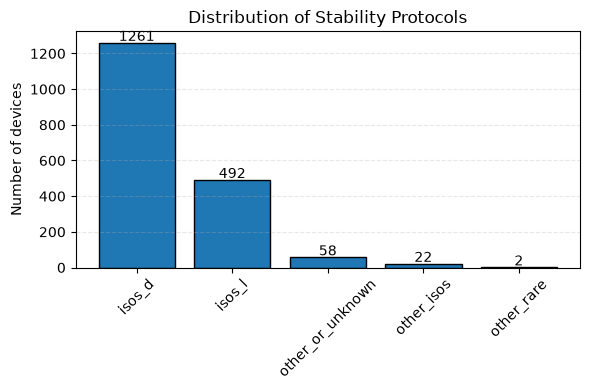

In [24]:
protocol_counts = stress_final["protocol_family"].value_counts(dropna=False)

plt.figure(figsize=(6,4))
plt.bar(protocol_counts.index, protocol_counts.values, edgecolor="black")

plt.ylabel("Number of devices")
plt.title("Distribution of Stability Protocols")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for i, v in enumerate(protocol_counts.values):
    plt.text(i, v + 10, str(v), ha="center")

plt.tight_layout()
plt.show()

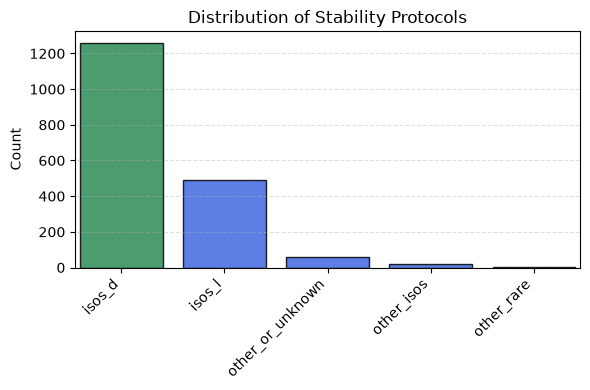

In [25]:
protocol_counts = stress_final["protocol_family"].value_counts(dropna=False)

plt.figure(figsize=(6,4))

colors = ["royalblue"] * len(protocol_counts)
colors[0] = "seagreen"

bars = plt.bar(protocol_counts.index.astype(str), protocol_counts.values,color=colors,edgecolor="black", alpha=0.85)

plt.ylabel("Count")
plt.title("Distribution of Stability Protocols")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.margins(x=0.01)
plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "protocol_distribution.png"), dpi=600)
plt.show()

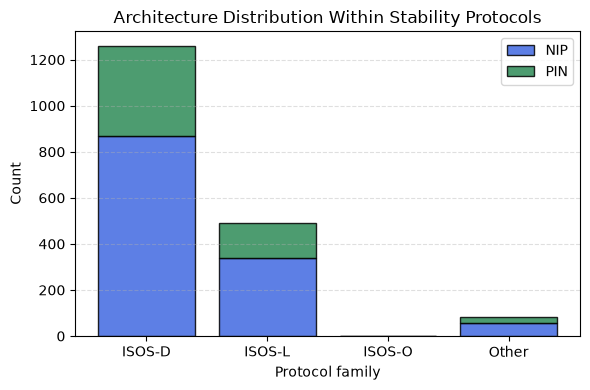

In [26]:
tmp = t80_df[["Cell_architecture", "Stability_protocol"]].copy()
tmp["arch_clean"] = (tmp["Cell_architecture"].astype(str) .str.strip().str.lower())
tmp["protocol_clean"] = (tmp["Stability_protocol"].astype(str).str.strip().str.lower())

def simplify_architecture(x):
    if "nip" in x:
        return "NIP"
    elif "pin" in x:
        return "PIN"
    else:
        return None

tmp["arch_group"] = tmp["arch_clean"].apply(simplify_architecture)

def simplify_protocol(x):
    if "isos-d" in x:
        return "ISOS-D"
    elif "isos-l" in x:
        return "ISOS-L"
    elif "isos-o" in x:
        return "ISOS-O"
    else:
        return "Other"

tmp["protocol_group"] = tmp["protocol_clean"].apply(simplify_protocol)
tmp = tmp.dropna(subset=["arch_group"])
cross = pd.crosstab(tmp["protocol_group"], tmp["arch_group"])
cross = cross.reindex(["ISOS-D", "ISOS-L", "ISOS-O", "Other"], fill_value=0)
cross = cross.reindex(columns=["NIP", "PIN"], fill_value=0)

plt.figure(figsize=(6,4))
plt.bar(cross.index,cross["NIP"],color="royalblue",edgecolor="black",alpha=0.85,label="NIP")
plt.bar(cross.index,cross["PIN"],bottom=cross["NIP"], color="seagreen", edgecolor="black",alpha=0.85,label="PIN")

plt.xlabel("Protocol family")
plt.ylabel("Count")
plt.title("Architecture Distribution Within Stability Protocols")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "protocol_vs_architecture.png"), dpi=600)
plt.show()

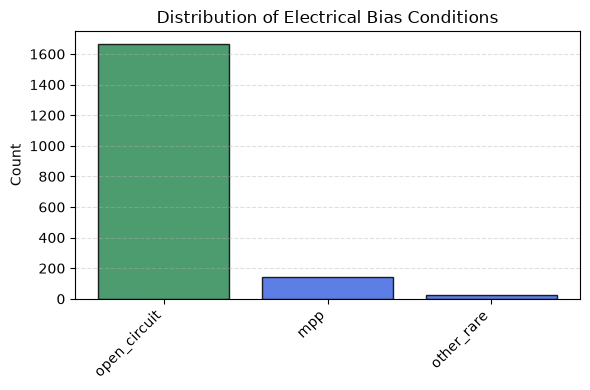

In [27]:
bias_counts = stress_final["bias_family"].value_counts(dropna=False)

bias_counts = bias_counts.sort_values(ascending=False)

plt.figure(figsize=(6,4))

colors = ["royalblue"] * len(bias_counts)
if len(colors) > 0:
    colors[0] = "seagreen"

bars = plt.bar(bias_counts.index.astype(str),bias_counts.values,color=colors,edgecolor="black",alpha=0.85)

plt.ylabel("Count")
plt.title("Distribution of Electrical Bias Conditions")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "bias_distribution.png"), dpi=600)
plt.show()

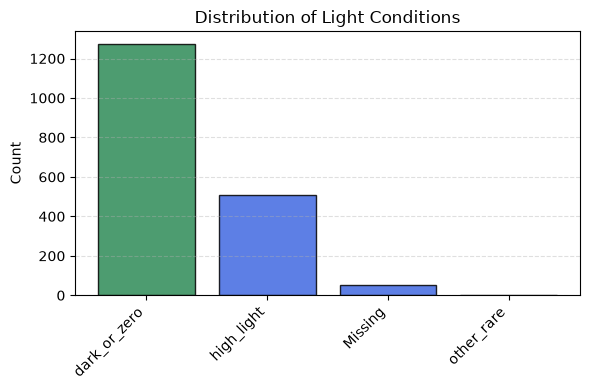

In [28]:
# Distribution of light conditions

light_counts = stress_final["light_bin"].value_counts(dropna=False)
light_counts = light_counts.sort_values(ascending=False)

# Convert every category label to text, including missing values
light_labels = [
    "Missing" if pd.isna(x) else str(x)
    for x in light_counts.index
]

plt.figure(figsize=(6,4))

colors = ["royalblue"] * len(light_counts)

if len(colors) > 0:
    colors[0] = "seagreen"

bars = plt.bar(
    light_labels,
    light_counts.values,
    color=colors,
    edgecolor="black",
    alpha=0.85
)

plt.ylabel("Count")
plt.title("Distribution of Light Conditions")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    os.path.join(ARTIFACT_DIR, "light_distribution.png"),
    dpi=600
)

plt.show()